#  Fase 1 — Comparació d'Algorismes: DQN RLCard / NFSP RLCard / DQN SB3 / PPO SB3

Aquesta fase compara quatre agents d'aprenentatge per reforç en el joc del Truc sota condicions homogènies: mateixa arquitectura de xarxa [256, 256], mateixa funció d'avaluació i el mateix entorn. L'objectiu és entendre les diferències fonamentals entre algorismes, llibreries i paradigmes d'entrenament **abans** d'escollir el millor candidat per a les fases posteriors.

Fem dues comparatives:
1. **Per timesteps** — qualitat assolida després del mateix nombre de passos d'entrenament.
2. **Per temps real** — qualitat assolida amb el mateix pressupost temporal (4 hores per agent).

---

## 1. Context teòric

### 1.1 Els quatre algorismes

| Agent | Llibreria | Paradigma | Self-play | Paral·lelisme |
|---|---|---|---|---|
| **DQN RLCard** | RLCard | Off-policy | Polyak averaging | No |
| **NFSP RLCard** | RLCard | Off-policy + Imitació | Self-play natiu | No |
| **DQN SB3** | Stable-Baselines3 | Off-policy | No | No |
| **PPO SB3** | Stable-Baselines3 | On-policy | No | 48 entorns (SubprocVecEnv) |

---

### 1.2 On-policy vs Off-policy

**Off-policy** (DQN, NFSP): l'agent aprèn d'un *replay buffer* que acumula transicions passades `(s, a, r, s')`. Permet reutilitzar experiències moltes vegades, cosa que és eficient en termes de mostres. La contrapartida és que el buffer pot quedar desactualitzat respecte la política actual.

**On-policy** (PPO): l'agent aprèn exclusivament de trajectòries generades per la política actual. Cada lot de dades es descarta un cop s'actualitza la xarxa. Requereix més mostres però és més estable i natural per a entorns amb canvis freqüents de l'oponent.

---

### 1.3 DQN — Deep Q-Network

DQN aprèn una funció de valor $Q(s, a)$ que estima la recompensa esperada per a cada acció en un estat. La xarxa s'actualitza minimitzant l'error de Bellman:

$$\mathcal{L} = \left( r + \gamma \max_{a'} Q_{\text{target}}(s', a') - Q(s, a) \right)^2$$

**Replay buffer**: guarda transicions passades i en mostra minilots aleatòriament per trencar la correlació temporal.  
**Target network**: còpia retardada de la xarxa principal per estabilitzar els objectius d'entrenament.

En aquest experiment, **DQN RLCard** usa *Polyak self-play*: l'oponent és una còpia suavitzada del learner actualitzada progressivament ($\tau = 0.05$), cosa que evita el col·lapse de self-play pur.

---

### 1.4 NFSP — Neural Fictitious Self-Play

NFSP combina DQN (política de millor resposta) amb aprenentatge per imitació per aproximar l'**estratègia mitjana** de fictitious play. En cada episodi, l'agent tria entre:
- La **millor resposta** actual (política RL, gredosa respecte $Q$).
- La **política mitjana** (xarxa supervisada entrenada per imitar l'historial de millors respostes).

El paràmetre $\eta$ (*anticipatory parameter*, 0.25) determina la proporció de vegades que s'usa la millor resposta.

**Connexió amb l'equilibri de Nash**: en jocs de suma zero amb dos jugadors, si tots dos agents fan NFSP simultàniament, les seves estratègies mitjanes convergeixen asimptòticament cap a un equilibri de Nash. A la pràctica això requereix self-play simètric; en el nostre cas NFSP juga contra ell mateix (p0 vs p1), cosa que afavoreix aquesta convergència.

El **reservoir buffer** (mostreig aleatori uniforme de tota la memòria) garanteix que la política supervisada no oblidi les primeres versions de l'agent.

---

### 1.5 PPO — Proximal Policy Optimization

PPO és un algorisme on-policy que optimitza directament la política $\pi_\theta$ maximitzant una funció objectiu *clipejada* per limitar canvis massa grans:

$$\mathcal{L}^{CLIP} = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t\right)\right]$$

on $r_t(\theta) = \pi_\theta(a|s) / \pi_{\theta_\text{old}}(a|s)$ és el rati de probabilitats i $\hat{A}_t$ és l'avantatge estimat via GAE.

La **gran avantatge de PPO en aquest context** és el paral·lelisme: usa 48 entorns simultanis (SubprocVecEnv), cosa que permet generar molts timesteps per segon i actualitzar la xarxa amb lots molt variats de transicions.

---

### 1.6 RLCard vs Stable-Baselines3

**RLCard** és un framework específic per a jocs de cartes. Proporciona agents (DQN, NFSP) ja integrats amb l'entorn i amb bucles d'entrenament personalitzables. La contrapartida és que no suporta paral·lelisme natiu.

**Stable-Baselines3** és un framework d'RL de propòsit general compatible amb la interfície Gymnasium. Els seus algorismes estan molt optimitzats i suporten entorns vectoritzats. Requereix adaptar l'entorn (`TrucGymEnv`) però a canvi es beneficia de totes les optimitzacions de SB3.

---

### 1.7 Repartiment d'oponents

**Distribució d'oponents durant l'entrenament** en aquest experiment:

| Agent | Random | AgentRegles | Self-play |
|---|---|---|---|
| **DQN RLCard** | 10% | 60% | 30% (Polyak) |
| **NFSP RLCard** | 10% | 60% | 30% (self-play natiu) |
| **DQN SB3** | 5% | 95% | — |
| **PPO SB3** | ~4% | ~96% | — |

**Per als agents RLCard**, el self-play és una part natural del disseny del framework:
- En **DQN RLCard**, el *Polyak self-play* ($\tau=0.05$) crea un oponent que evoluciona al ritme de l'agent, evitant que el learner sobreajusti contra un oponent estàtic i generant un curriculum progressiu de dificultat creixent.
- En **NFSP**, el self-play és estructural a l'algorisme: NFSP per definició entrena dos agents (p0 vs p1) simultàniament. Sense self-play, NFSP perd la seva propietat de convergència cap a l'equilibri de Nash.

**Per als agents SB3**, afegir self-play planteja dificultats tècniques significatives:
- **PPO** usa 48 subprocessos independents (`SubprocVecEnv`). Sincronitzar periòdicament els pesos del learner cap a tots els oponents dels subprocessos requeriria mecanismes d'IPC complexos i podria degradar el throughput.
- **DQN SB3** seria tècnicament assequible (un sol procés), però s'ha mantingut sense self-play per coherència amb PPO i per no introduir variables addicionals en aquesta fase comparativa.

**Implicació metodològica**: aquesta asimetria significa que els agents RLCard entrenen contra un adversari que co-evoluciona (potencialment més difícil i instructiu a mesura que l'agent millora), mentre que els agents SB3 sempre veuen el mateix `AgentRegles` estàtic. Les diferències de rendiment observades, per tant, podrien reflectir tant la qualitat intrínseca de l'algorisme com l'efecte del curriculum d'entrenament. Aquesta és una **limitació reconeguda** d'aquesta fase comparativa inicial.

---

## 2. Setup

In [1]:
import sys
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot, suavitzar, carregar_logs as _carregar_logs

setup_pyplot(dpi=130)

COLORS = {
    'dqn_rlcard':  '#2196F3',
    'nfsp_rlcard': '#4CAF50',
    'dqn_sb3':     '#FF9800',
    'ppo_sb3':     '#E91E63',
}
LABELS = {
    'dqn_rlcard':  'DQN RLCard',
    'nfsp_rlcard': 'NFSP RLCard',
    'dqn_sb3':     'DQN SB3',
    'ppo_sb3':     'PPO SB3',
}
AGENTS = list(COLORS.keys())
NOTEBOOK_DIR = Path('.')

def carregar_resultats(base_dir: Path) -> dict:
    return _carregar_logs(base_dir, AGENTS)

def llegir_resum_temps(base_dir: Path) -> dict[str, float]:
    resum = {}
    path = base_dir / 'resum_temps.txt'
    if not path.exists():
        return resum
    for line in path.read_text(encoding='utf-8').splitlines():
        for agent in AGENTS:
            if line.startswith(agent + ':') or line.startswith(agent.replace('_', ' ') + ':'):
                try:
                    resum[agent] = int(line.split(':')[1].strip().split('s')[0])
                except Exception:
                    pass
    return resum

print("Setup complet.")


Setup complet.

In [2]:
# Ruta de resultats per timesteps (ja existent)
resultats_ts_dirs = sorted(NOTEBOOK_DIR.glob('resultats_fase1_*[!temps_]*'))
# Filtrar les que no siguin de temps
resultats_ts_dirs = [d for d in resultats_ts_dirs if 'temps' not in d.name]

if resultats_ts_dirs:
    DIR_TS = resultats_ts_dirs[-1]  # última execució
    print(f"Resultats timesteps: {DIR_TS.name}")
    dades_ts = carregar_resultats(DIR_TS)
    resum_ts  = llegir_resum_temps(DIR_TS)
    for a, df in dades_ts.items():
        print(f"  {LABELS[a]}: {len(df)} avaluacions, fins step {df['step'].max():,}")
else:
    dades_ts = {}
    resum_ts  = {}
    print("No s'han trobat resultats per timesteps.")

Resultats timesteps: resultats_fase1_09_04_1014h
  DQN RLCard: 20 avaluacions, fins step 5,000,011
  NFSP RLCard: 20 avaluacions, fins step 5,000,010
  DQN SB3: 20 avaluacions, fins step 5,000,000
  PPO SB3: 20 avaluacions, fins step 5,000,640

---

## 3. Comparativa per Timesteps

Cada agent ha estat entrenat fins a **5M timesteps** amb el mateix protocol d'avaluació (cada 500k steps: 50 partides vs Random + 100 partides vs AgentRegles).

La mètrica composta és: `metric = 0.25 × wr_random + 0.75 × wr_regles`

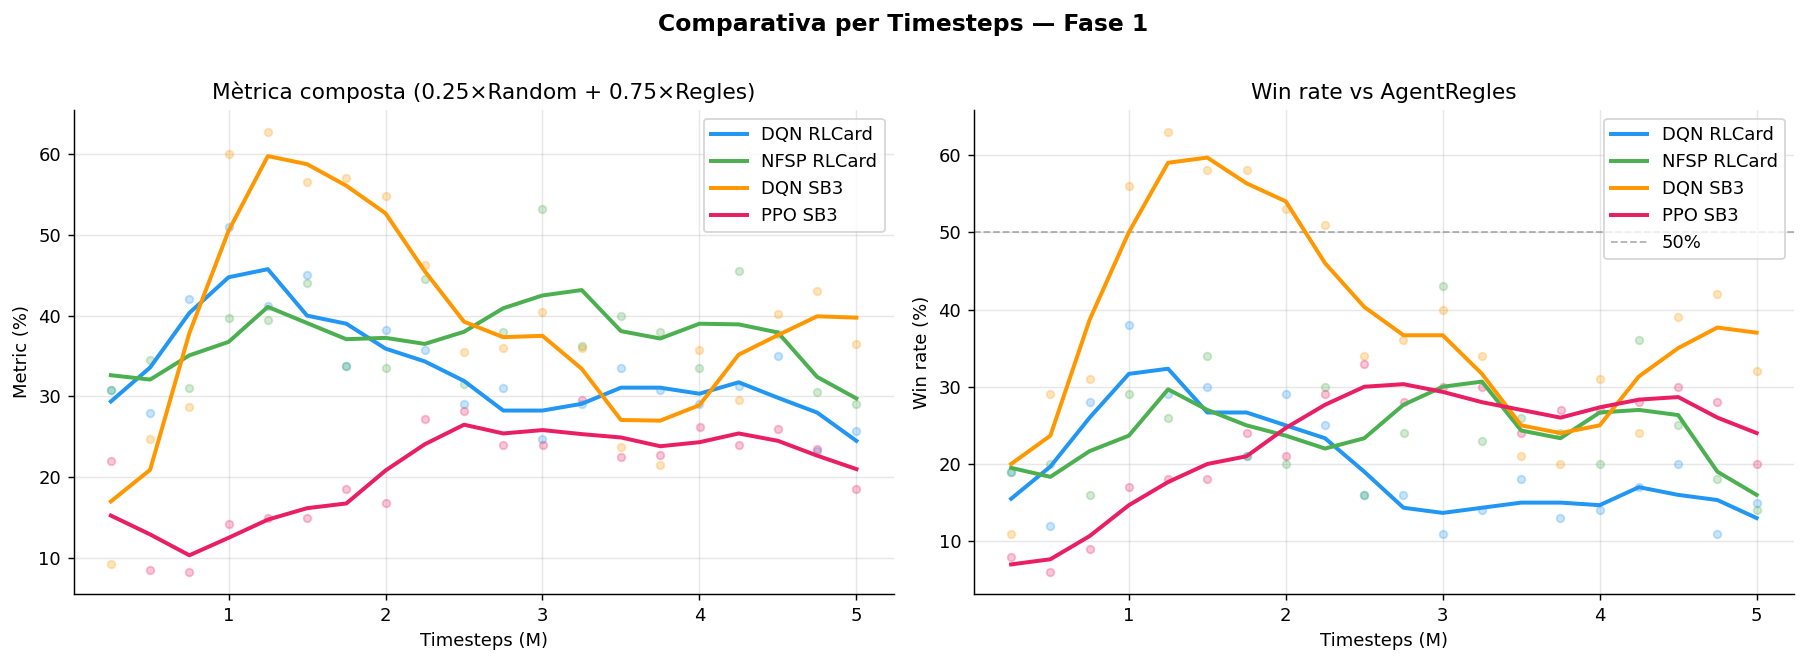

In [3]:
WINDOW_TS = 3  # finestra petita: només 20 punts per agent

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_metric, ax_regles = axes

for agent, df in dades_ts.items():
    steps_m = df['step'] / 1_000_000
    color    = COLORS[agent]
    label    = LABELS[agent]

    # Dades brutes (punts discrets, transparents)
    ax_metric.scatter(steps_m, df['eval_metric'],
                      color=color, alpha=0.25, s=18, zorder=2)
    ax_regles.scatter(steps_m, df['eval_wr_regles'],
                      color=color, alpha=0.25, s=18, zorder=2)

    # Línia suavitzada (mitjana mòbil centrada)
    sm_metric = suavitzar(df['eval_metric'], WINDOW_TS)
    sm_regles = suavitzar(df['eval_wr_regles'], WINDOW_TS)

    ax_metric.plot(steps_m, sm_metric,
                   color=color, label=label, linewidth=2.2, zorder=3)
    ax_regles.plot(steps_m, sm_regles,
                   color=color, label=label, linewidth=2.2, zorder=3)

ax_metric.set_title('Mètrica composta (0.25×Random + 0.75×Regles)')
ax_metric.set_xlabel('Timesteps (M)')
ax_metric.set_ylabel('Metric (%)')
ax_metric.legend()

ax_regles.set_title('Win rate vs AgentRegles')
ax_regles.set_xlabel('Timesteps (M)')
ax_regles.set_ylabel('Win rate (%)')
ax_regles.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50%')
ax_regles.legend()

plt.suptitle('Comparativa per Timesteps — Fase 1', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
rows = []
for agent, df in dades_ts.items():
    best_metric = df['eval_metric'].max()
    final_metric = df['eval_metric'].iloc[-1]
    best_wr_regles = df['eval_wr_regles'].max()
    final_wr_regles = df['eval_wr_regles'].iloc[-1]
    elapsed = df['elapsed_s'].iloc[-1]
    total_steps = df['step'].iloc[-1]
    temps_resum = resum_ts.get(agent, elapsed)
    rows.append({
        'Agent': LABELS[agent],
        'Steps finals': f"{total_steps/1e6:.2f}M",
        'Millor metric (%)': f"{best_metric:.1f}",
        'Metric final (%)': f"{final_metric:.1f}",
        'Millor WR Regles (%)': f"{best_wr_regles:.1f}",
        'WR Regles final (%)': f"{final_wr_regles:.1f}",
        'Temps total': f"{int(temps_resum)//3600}h {(int(temps_resum)%3600)//60}m" if temps_resum else f"{elapsed:.0f}s",
    })

df_resum_ts = pd.DataFrame(rows)
df_resum_ts.set_index('Agent', inplace=True)
df_resum_ts

,Steps finals,Millor metric (%),Metric final (%),Millor WR Regles (%),WR Regles final (%),Temps total
Agent,,,,,,
DQN RLCard,5.00M,51.0,25.8,38.0,15.0,0h 54m
NFSP RLCard,5.00M,53.2,29.0,43.0,14.0,3h 52m
DQN SB3,5.00M,62.8,36.5,63.0,32.0,0h 43m
PPO SB3,5.00M,29.5,18.5,33.0,20.0,0h 8m


**Observacions per timesteps:**

- **DQN SB3** aconsegueix la millor mètrica puntual (62.8%) i el millor WR vs Regles (63%), però s'inestabilitza cap al final.
- **NFSP RLCard** mostra la millor consistència inicial però és molt lent (4h per 5M steps) per la seva complexitat de training.
- **PPO SB3** és l'agent més ràpid en temps real (8 min!) però amb 5M timesteps no ha tingut prou mostres per aprendre correctament.
- Tots els agents mostren **regressió cap al final**: la dificultat del Truc i l'exploració decaient causen inestabilitat.

---

## 4. Comparativa per Temps Real (4 hores per agent)

Amb el mateix pressupost temporal, cada agent pot completar un nombre molt diferent de timesteps. Aquesta comparativa mostra la qualitat assolida respecte el temps de càlcul invertit.

In [5]:
resultats_temps_dirs = sorted(NOTEBOOK_DIR.glob('resultats_fase1_temps_*'))

if resultats_temps_dirs:
    DIR_TEMPS = resultats_temps_dirs[-1]
    print(f"Resultats temps: {DIR_TEMPS.name}")
    dades_temps = carregar_resultats(DIR_TEMPS)
    resum_temps_dict = llegir_resum_temps(DIR_TEMPS)
    for a, df in dades_temps.items():
        steps = df['step'].iloc[-1]
        t_real = df['elapsed_s'].iloc[-1]
        print(f"  {LABELS[a]}: {len(df)} avaluacions, {steps/1e6:.2f}M steps en {t_real/3600:.2f}h")
else:
    dades_temps = {}
    resum_temps_dict = {}
    print("No hi ha resultats per temps")

Resultats temps: resultats_fase1_temps_09_04_2141h
  DQN RLCard: 34 avaluacions, 17.00M steps en 3.88h
  NFSP RLCard: 10 avaluacions, 5.00M steps en 3.89h
  DQN SB3: 68 avaluacions, 34.00M steps en 3.98h
  PPO SB3: 314 avaluacions, 157.01M steps en 3.99h

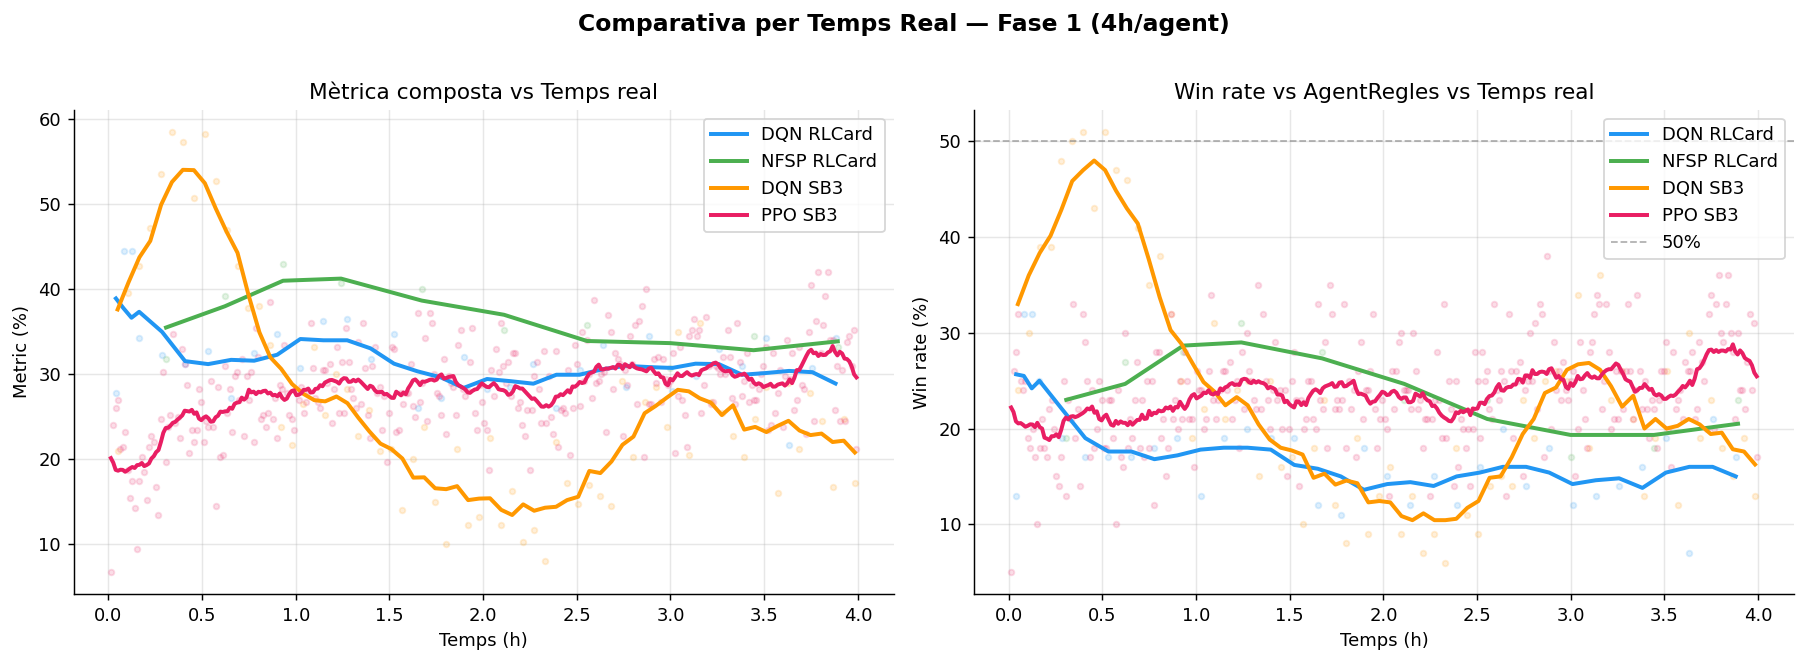

In [6]:
if dades_temps:
    WINDOW_TEMPS = {
        'dqn_rlcard':  5,
        'nfsp_rlcard': 3,
        'dqn_sb3':     7,
        'ppo_sb3':     20,
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax_metric, ax_regles = axes

    for agent, df in dades_temps.items():
        elapsed_h = df['elapsed_s'] / 3600
        color     = COLORS[agent]
        label     = LABELS[agent]
        w         = WINDOW_TEMPS[agent]

        # Dades brutes (punts discrets, molt transparents)
        ax_metric.scatter(elapsed_h, df['eval_metric'],
                          color=color, alpha=0.15, s=10, zorder=2)
        ax_regles.scatter(elapsed_h, df['eval_wr_regles'],
                          color=color, alpha=0.15, s=10, zorder=2)

        # Línia suavitzada
        sm_metric = suavitzar(df['eval_metric'], w)
        sm_regles = suavitzar(df['eval_wr_regles'], w)

        ax_metric.plot(elapsed_h, sm_metric,
                       color=color, label=label, linewidth=2.2, zorder=3)
        ax_regles.plot(elapsed_h, sm_regles,
                       color=color, label=label, linewidth=2.2, zorder=3)

    ax_metric.set_title('Mètrica composta vs Temps real')
    ax_metric.set_xlabel('Temps (h)')
    ax_metric.set_ylabel('Metric (%)')
    ax_metric.legend()

    ax_regles.set_title('Win rate vs AgentRegles vs Temps real')
    ax_regles.set_xlabel('Temps (h)')
    ax_regles.set_ylabel('Win rate (%)')
    ax_regles.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50%')
    ax_regles.legend()

    plt.suptitle('Comparativa per Temps Real — Fase 1 (4h/agent)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Sense dades de temps. Executa run_fase1_temps.sh primer.")

In [7]:
if dades_temps:
    rows_t = []
    for agent, df in dades_temps.items():
        best_metric = df['eval_metric'].max()
        final_metric = df['eval_metric'].iloc[-1]
        best_wr_regles = df['eval_wr_regles'].max()
        total_steps = df['step'].iloc[-1]
        rows_t.append({
            'Agent': LABELS[agent],
            'Steps completats en 4h': f"{total_steps/1e6:.1f}M",
            'Millor metric (%)': f"{best_metric:.1f}",
            'Metric final (%)': f"{final_metric:.1f}",
            'Millor WR Regles (%)': f"{best_wr_regles:.1f}",
        })
    df_resum_temps = pd.DataFrame(rows_t).set_index('Agent')
    display(df_resum_temps)
else:
    print("Sense dades de temps. Executa run_fase1_temps.sh primer.")

,Steps completats en 4h,Millor metric (%),Metric final (%),Millor WR Regles (%)
Agent,,,,
DQN RLCard,17.0M,44.5,34.2,32.0
NFSP RLCard,5.0M,43.0,33.2,31.0
DQN SB3,34.0M,58.5,17.2,51.0
PPO SB3,157.0M,42.0,21.2,38.0


**Observacions per temps real (4h per agent):**

| Agent | Steps en 4h | Millor metric | Metric final |
|---|---|---|---|
| **DQN SB3** | 34M | **58.5%** | 17.2% |
| **DQN RLCard** | 17M | 44.5% | 34.2% |
| **NFSP RLCard** | 5M | 43.0% | 33.2% |
| **PPO SB3** | **157M** | 42.0% | 21.2% |

- **DQN SB3** segueix sent el millor en 4h (58.5%) malgrat generar molts menys timesteps que PPO. El seu aprenentatge és molt eficient per pas.
- **PPO SB3** genera 157M steps (4.6× més que DQN SB3) però la seva millor mètrica (42%) és inferior. Amb on-policy i entorns paral·lels necessita molts passos per estabilitzar-se — en 4h no ha tingut prou "profunditat" d'exploració.
- **DQN RLCard i NFSP** s'igualen en 4h (44.5% vs 43%), però DQN RLCard és molt més estable al final (34.2% vs 33.2%). NFSP amb tan sols 5M steps no ha tingut temps de madurar la seva estratègia mitjana.
- **Inestabilitat generalitzada**: tots els agents degraden cap al final de l'entrenament. DQN SB3 és el cas més extrem: millor metric 58.5% però final 17.2%.

---

## 5. Throughput — Timesteps per Hora

Mesurem quants timesteps genera cada agent per hora de càlcul (throughput). Aquesta mètrica és clau per entendre l'avantatge del paral·lelisme de PPO.

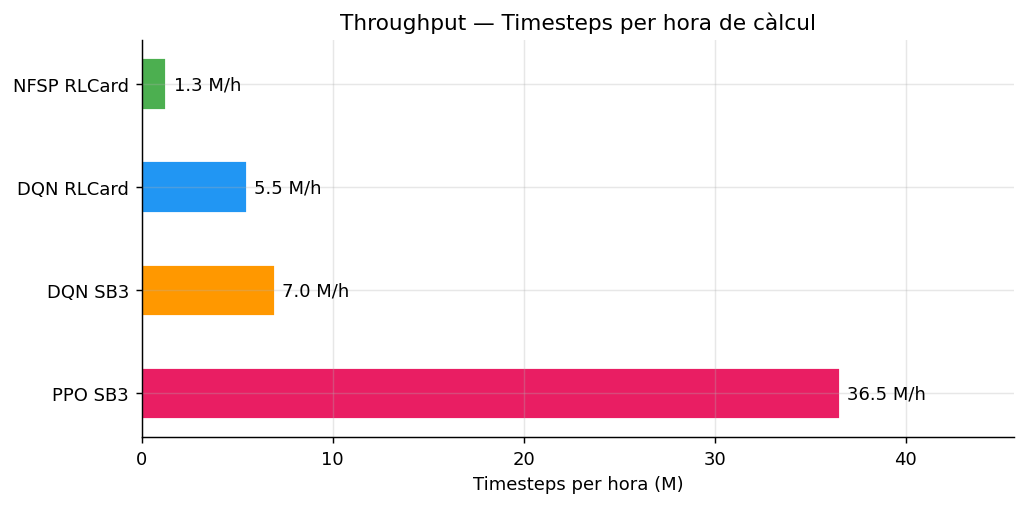


Throughput:
  PPO SB3: 36.5 M steps/hora
  DQN SB3: 7.0 M steps/hora
  DQN RLCard: 5.5 M steps/hora
  NFSP RLCard: 1.3 M steps/hora

In [8]:
# Throughput basat en dades de timesteps (temps real mesurat)
throughput = {}
for agent, df in dades_ts.items():
    steps = df['step'].iloc[-1]
    elapsed_h = df['elapsed_s'].iloc[-1] / 3600
    if elapsed_h > 0:
        throughput[agent] = steps / elapsed_h / 1_000_000  # en M steps/hora

if throughput:
    fig, ax = plt.subplots(figsize=(8, 4))
    agents_sorted = sorted(throughput, key=throughput.get, reverse=True)
    vals = [throughput[a] for a in agents_sorted]
    bars = ax.barh([LABELS[a] for a in agents_sorted], vals,
                   color=[COLORS[a] for a in agents_sorted], edgecolor='white', height=0.5)
    ax.bar_label(bars, fmt='{:.1f} M/h', padding=4)
    ax.set_xlabel('Timesteps per hora (M)')
    ax.set_title('Throughput — Timesteps per hora de càlcul')
    ax.set_xlim(0, max(vals) * 1.25)
    plt.tight_layout()
    plt.show()

    print("\nThroughput:")
    for a in agents_sorted:
        print(f"  {LABELS[a]}: {throughput[a]:.1f} M steps/hora")
else:
    print("Sense dades de throughput.")

**Insight sobre el throughput:**

- **PPO SB3** genera **36.5M steps/hora** gràcies als 48 entorns paral·lels — és **28× més ràpid que NFSP** i **5× més ràpid que DQN SB3**.
- **NFSP RLCard** és el més lent (1.3M steps/hora) per la seva arquitectura complexa: dues xarxes, dos replay buffers i el bucle seqüencial sense paral·lelisme.
- Amb 4 hores de pressupost, PPO pot generar ~146M timesteps mentre NFSP només ~5M.

Això explica per què la comparativa **per temps** pot donar resultats molt diferents que la comparativa **per timesteps**: un agent que sembla pitjor a igual nombre de passos pot resultar molt millor amb el mateix temps de càlcul.

---

## 6. Conclusions

### Per Timesteps (5M steps)

| Agent | Millor metric | Metric final | Temps real |
|---|---|---|---|
| **DQN SB3** | **62.8%** | 36.5% | 43 min |
| **NFSP RLCard** | 53.2% | 29.0% | 3h 52m |
| **DQN RLCard** | 51.0% | 25.8% | 54 min |
| **PPO SB3** | 29.5% | 18.5% | **8 min** |

### Per Temps Real (4 hores per agent)

| Agent | Steps completats | Millor metric | Metric final |
|---|---|---|---|
| **DQN SB3** | 34M | **58.5%** | 17.2% |
| **DQN RLCard** | 17M | 44.5% | 34.2% |
| **NFSP RLCard** | 5M | 43.0% | 33.2% |
| **PPO SB3** | **157M** | 42.0% | 21.2% |

### Throughput (steps per hora)

| Agent | Steps/hora | Factor respecte NFSP |
|---|---|---|
| **PPO SB3** | 36.5M/h | 28× |
| **DQN SB3** | 7.0M/h | 5.4× |
| **DQN RLCard** | 5.5M/h | 4.2× |
| **NFSP RLCard** | 1.3M/h | 1× (referència) |

---

### Conclusions generals

**1. DQN SB3 és l'agent més eficient fins ara.**
Guanya tant per timestep (62.8%) com per temps (58.5%). Aprèn de forma molt eficient, però mostra degradació severa al final — la seva millor mètrica (58.5%) és molt millor que la final (17.2%), cosa que indica inestabilitat d'entrenament llarg.

**2. PPO necessita una finestra de temps molt més gran per lluir.**
Amb 157M steps en 4h obté tan sols un 42% de millor mètrica — similar a DQN RLCard amb 17M steps. Però el potencial és clar: un cop l'exploració es consolida i es dóna prou temps per la convergència on-policy, les corbes podrien superar els agents off-policy.

**3. Off-policy (DQN, NFSP) és més eficient per mostres.**
Aprofiten millor cada timestep individual gràcies al replay buffer, però el seu límit és la velocitat de generació d'experiència (seqüencial).

**4. La comparativa per temps canvia el rànquing.**
Comparant a 5M steps: DQN SB3 > NFSP > DQN RLCard > PPO.
Comparant a 4h: DQN SB3 > DQN RLCard ≈ NFSP > PPO.
PPO puja lleugerament en la comparativa per temps però segueix per darrere. En entrenaments més llargs (>10h), el paral·lelisme de PPO podria marcar la diferència.

**5. Inestabilitat generalitzada.**
Tots els agents mostren regressió cap al final. Causes probables: epsilon massa baix, distribució d'oponents poc diversa, o manca de regularització.

---

## 7. Motivació de la Fase 2

Tots els camins explorats (més steps, més temps, més paral·lelisme, off-policy amb replay gegant, on-policy amb 48 entorns) xoquen contra el mateix sostre (~30–40% de mètrica). La conclusió natural és que el coll d'ampolla **no és el tipus l'algorisme, és la formulació del problema**:

- **Horitzó llarg**: una partida sencera fins a 24 punts pot durar desenes de mans. El reward final (±1) arriba massa tard per donar un *credit assignment* estable.
- **Reward sparse**: el *reward shaping* intermedi de `TrucGame` (±(pts_truc+pts_envit)/24 × 5.0) mitiga el problema però no el resol — continua dominat per la variància del gradient.
- **Doble aprenentatge acoblat**: l'agent ha d'aprendre alhora la **tàctica local** (quina carta jugar, quan apostar) i la **gestió estratègica global** (com administrar el marcador fins a 24 punts). Dos problemes amb dinàmiques molt diferents compartint la mateixa funció de pèrdua.

Continuar augmentant hiperparàmetres o hores no trencarà aquest sostre; l'Experiment 2 (4h per agent) ho confirma empíricament. Cal **reformular el problema**, i aquí és on entra la Fase 2:

1. **Factoritzar el problema**: separar la tàctica local (una mà) de l'estratègia global (una partida). Cada mà és una unitat natural del joc amb reward calculable al final i durada acotada (~10–20 steps).
2. **Curriculum learning**: entrenar primer sobre mans aïllades (horizon curt, reward dens) per aprendre heurístiques locals sòlides, i després fer **finetune** sobre partides senceres amb els pesos ja inicialitzats.

La hipòtesi experimental de la Fase 2 és directa: *si el sostre de la Fase 1 és estructural, canviar l'estructura del problema hauria de trencar-lo*. El marc teòric complet (motivació, entorn `TrucEnvMa`, riscos de *catastrophic forgetting* i mitigacions) es desenvolupa al document [`7_Fase2_MarcTeoric`](../../7_Fase2_MarcTeoric.md), i la implementació experimental amb els seus resultats al [`8_Fase2_Implementacio`](../../8_Fase2_Implementacio.md) i al notebook [`comparacio_fase2.ipynb`](../2_curriculum_learning/comparacio_fase2.ipynb).